In [51]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [52]:
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [53]:
def prepare_telco_df(df):
    """
    Preprocesses the Telco Customer Churn DataFrame.

    Args:
        df (pd.DataFrame): Raw Telco customer churn DataFrame.

    Returns:
        pd.DataFrame: Cleaned and preprocessed DataFrame ready for modeling.
    """
    
    # Drop unnecessary columns
    if 'customerID' in df.columns:
        df = df.drop('customerID', axis=1)
    
    # Convert TotalCharges to numeric and fill missing values
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(0)
    
    # Binary encoding for Yes/No columns
    binary_cols = ['Partner', 'Dependents', 'PaperlessBilling', 'Churn', 'PhoneService']
    df[binary_cols] = df[binary_cols].map(lambda x: 1 if x == 'Yes' else 0)
    
    # Encode gender
    df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
    
    # Encode MultipleLines
    df['MultipleLines'] = df['MultipleLines'].map({'No phone service': 0, 'No': 0, 'Yes': 1})
    
    # Encode service-related columns
    service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
    df[service_cols] = df[service_cols].map(lambda x: 1 if x == 'Yes' else 0)
    
    # One-hot encode categorical columns
    categorical_cols = ['InternetService', 'Contract', 'PaymentMethod']
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    
    return df

In [54]:
data = prepare_telco_df(data)

In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

In [56]:
data.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
MultipleLines                            0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMeth

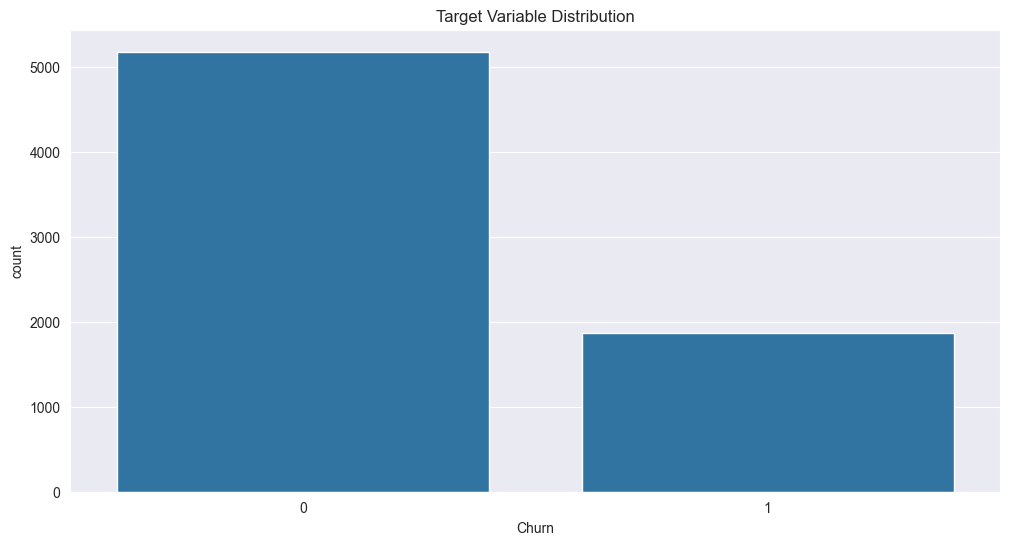

In [57]:
# DISTRIBUTION OF TARGET VARIABLE CLASSES
sns.set_style('darkgrid')
plt.figure(figsize=(12, 6))
sns.countplot(x = 'Churn', data = data)
plt.title('Target Variable Distribution')
plt.show()

the dataset is imbalanced l will apply and test several balancing techniques to ensure that the data is balanced( will test several hybrid data level techniques to avoid noise and class overlap during interpolation)

In [58]:
from collections import Counter
print(Counter(data.Churn))

Counter({0: 5174, 1: 1869})


In [59]:

### LETS CALCULATE THE IMBALANCED RATIO TO SEE THE DEGREE OF IMBALANCE
## IR =(NUMBER OF MAJORTY CLASS INSTANCES)/(NUMBER OF MINORITY CLASS INSTANCES)
IR = 5174/1869
print(IR)

2.7683253076511503


In [60]:
X = data.drop('Churn', axis=1)
y = data[['Churn']]

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler,OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
import random
SEED =2024
random.seed(SEED)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, cross_validate
from collections import Counter
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from imblearn.over_sampling import SMOTENC
from scipy import stats
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score, roc_auc_score, make_scorer, confusion_matrix
from imblearn.metrics import sensitivity_score,specificity_score
from sklearn.model_selection import cross_val_score, cross_validate
from collections import Counter
import scipy.stats as stat
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score,accuracy_score,f1_score, cohen_kappa_score
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.svm import SVC
from collections import Counter
from sklearn.model_selection import train_test_split
import os
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold
import pickle
from imblearn.pipeline import Pipeline, make_pipeline

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025, stratify = y)

To balance the two classes in the data 3 methods were compared


1. SMOTEENN >>> This technique is used because it contributes to comprehensive data cleaning. Here, further examples from both classes are removed to ensure noise reduction caused by SMOTE.
2. ADASYN >>> It adaptively modifies the sampling density based on the difficulty of learning regions and producing synthetic samples in places where the minority class is underrepresented, therefore making it better than SMOTE

In [63]:
#### lets apply smote-enn
from imblearn.combine import SMOTEENN
samp_pipeline = SMOTEENN(random_state=42)
X_S_ENN, y_S_ENN = samp_pipeline.fit_resample(X_train, y_train)

In [64]:
y

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


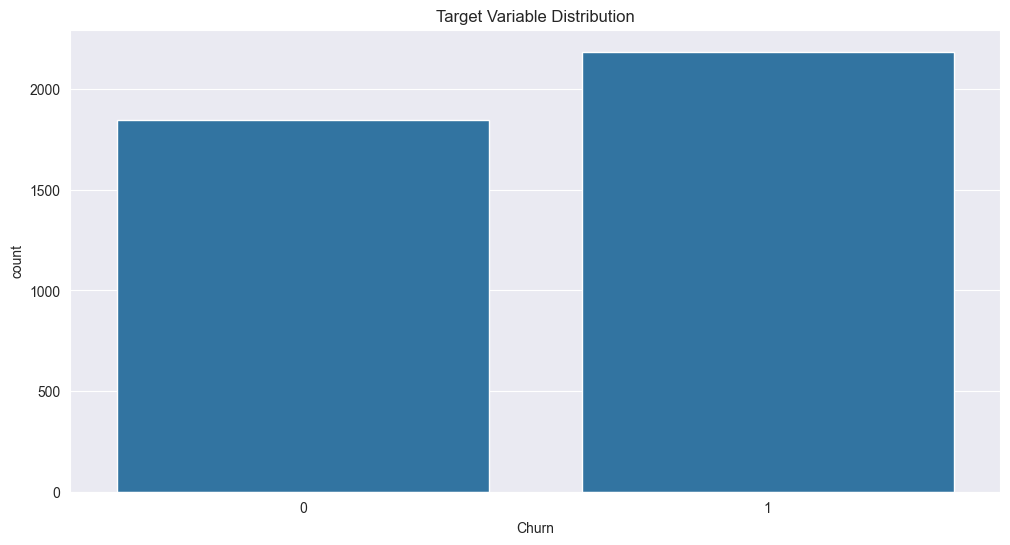

In [65]:
# DISTRIBUTION OF TARGET VARIABLE CLASSES
sns.set_style('darkgrid')
plt.figure(figsize=(12, 6))
sns.countplot(x = 'Churn', data = y_S_ENN)
plt.title('Target Variable Distribution')
plt.show()

In [66]:
####lets apply adasyn

from imblearn.over_sampling import ADASYN
ada = ADASYN(random_state=42)
X_res, y_res = ada.fit_resample(X_train, y_train)

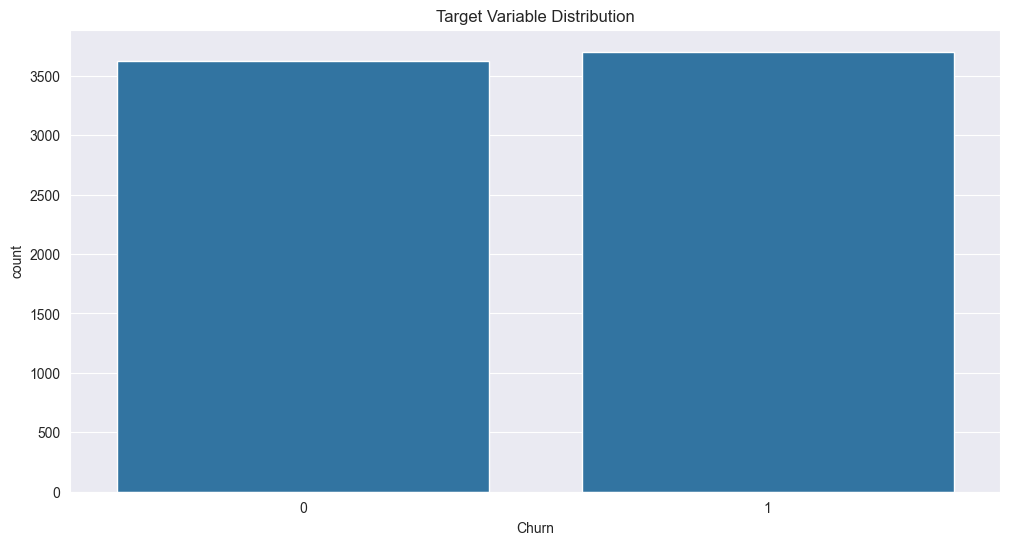

In [67]:
# DISTRIBUTION OF TARGET VARIABLE CLASSES
sns.set_style('darkgrid')
plt.figure(figsize=(12, 6))
sns.countplot(x = 'Churn', data = y_res)
plt.title('Target Variable Distribution')
plt.show()

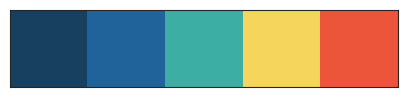

In [68]:
####### lets check for consistency of the methods
from tqdm import tqdm

# Modelling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, roc_auc_score
from sklearn import metrics


sns.set_style("white")

### Define the colour scheme
c1 = "#173f5f"
c2 = "#20639b"
c3 = "#3caea3"
c4 = "#f6d55c"
c5 = "#ed553b"

custom_palette = [c1, c2, c3, c4, c5]
sns.palplot(sns.color_palette(custom_palette))

In [69]:
####smote-enn

for sample_frac in tqdm(np.arange(20, 105, 5)):
    
    sampling_strategy = sample_frac/100
    train_data = RandomForestClassifier()
    clf = train_data.fit(X_S_ENN, y_S_ENN)
    
    # Make predictions
    y_pred = clf.predict(X_test)
    y_pred_bin = (y_pred > 0.5).astype("int")

    # Calculate ROC AUC score
    roc_auc = metrics.roc_auc_score(y_test, y_pred)
    f1_score = metrics.f1_score(y_test, y_pred_bin)
    precision_score = metrics.precision_score(y_test, y_pred_bin)
    recall_score = metrics.recall_score(y_test, y_pred_bin)

    if sample_frac == 20:
        df_result_enn = pd.DataFrame({'frac': [sampling_strategy], 'roc': [roc_auc], 'f1': [f1_score], 'precision': [precision_score], 'recall': [recall_score]})
    else:
        df_tmp = pd.DataFrame({'frac': [sampling_strategy], 'roc': [roc_auc], 'f1': [f1_score], 'precision': [precision_score], 'recall': [recall_score]})
        df_result_enn = pd.concat([df_result_enn, df_tmp], ignore_index=True, axis=0)
        
df_result_enn.head() 

100%|██████████| 17/17 [00:07<00:00,  2.24it/s]


,frac,roc,f1,precision,recall
0,0.20,0.752360,0.619297,0.533505,0.737968
1,0.25,0.755185,0.623123,0.538262,0.739750
2,0.30,0.751469,0.618263,0.532903,0.736185
3,0.35,0.754239,0.620741,0.531052,0.746881
4,0.40,0.753574,0.620793,0.534794,0.739750


In [70]:
####adasyn

for sample_frac in tqdm(np.arange(20, 105, 5)):
    
    sampling_strategy = sample_frac/100
    train_data = RandomForestClassifier()
    clf = train_data.fit(X_res, y_res)
    
    # Make predictions
    y_pred = clf.predict(X_test)
    y_pred_bin = (y_pred > 0.5).astype("int")

    # Calculate ROC AUC score
    roc_auc = metrics.roc_auc_score(y_test, y_pred)
    f1_score = metrics.f1_score(y_test, y_pred_bin)
    precision_score = metrics.precision_score(y_test, y_pred_bin)
    recall_score = metrics.recall_score(y_test, y_pred_bin)

    if sample_frac == 20:
        df_result_ada = pd.DataFrame({'frac': [sampling_strategy], 'roc': [roc_auc], 'f1': [f1_score], 'precision': [precision_score], 'recall': [recall_score]})
    else:
        df_tmp = pd.DataFrame({'frac': [sampling_strategy], 'roc': [roc_auc], 'f1': [f1_score], 'precision': [precision_score], 'recall': [recall_score]})
        df_result_ada = pd.concat([df_result_ada, df_tmp], ignore_index=True, axis=0)
        
df_result_ada.head() 

100%|██████████| 17/17 [00:16<00:00,  1.02it/s]


,frac,roc,f1,precision,recall
0,0.20,0.720384,0.587826,0.573854,0.602496
1,0.25,0.710881,0.575245,0.574733,0.575758
2,0.30,0.714543,0.579965,0.571924,0.588235
3,0.35,0.714146,0.579178,0.568729,0.590018
4,0.40,0.714468,0.579685,0.569707,0.590018


In [71]:
df_result_enn_rename = df_result_enn.copy()
df_result_ada_rename = df_result_ada.copy()
df_result_enn_rename = df_result_enn_rename.rename(columns={'roc':'roc_enn', 'f1':'f1_enn', 'precision':'precision_enn', 'recall':'recall_enn'})
df_result_ada_rename = df_result_ada_rename.rename(columns={'roc':'roc_ada', 'f1':'f1_ada', 'precision':'precision_ada', 'recall':'recall_ada'})

In [72]:
df_result = df_result_ada_rename.merge(df_result_enn_rename, on='frac', how='left')

df_result.head()

,frac,roc_ada,f1_ada,precision_ada,recall_ada,roc_enn,f1_enn,precision_enn,recall_enn
0,0.20,0.720384,0.587826,0.573854,0.602496,0.752360,0.619297,0.533505,0.737968
1,0.25,0.710881,0.575245,0.574733,0.575758,0.755185,0.623123,0.538262,0.739750
2,0.30,0.714543,0.579965,0.571924,0.588235,0.751469,0.618263,0.532903,0.736185
3,0.35,0.714146,0.579178,0.568729,0.590018,0.754239,0.620741,0.531052,0.746881
4,0.40,0.714468,0.579685,0.569707,0.590018,0.753574,0.620793,0.534794,0.739750


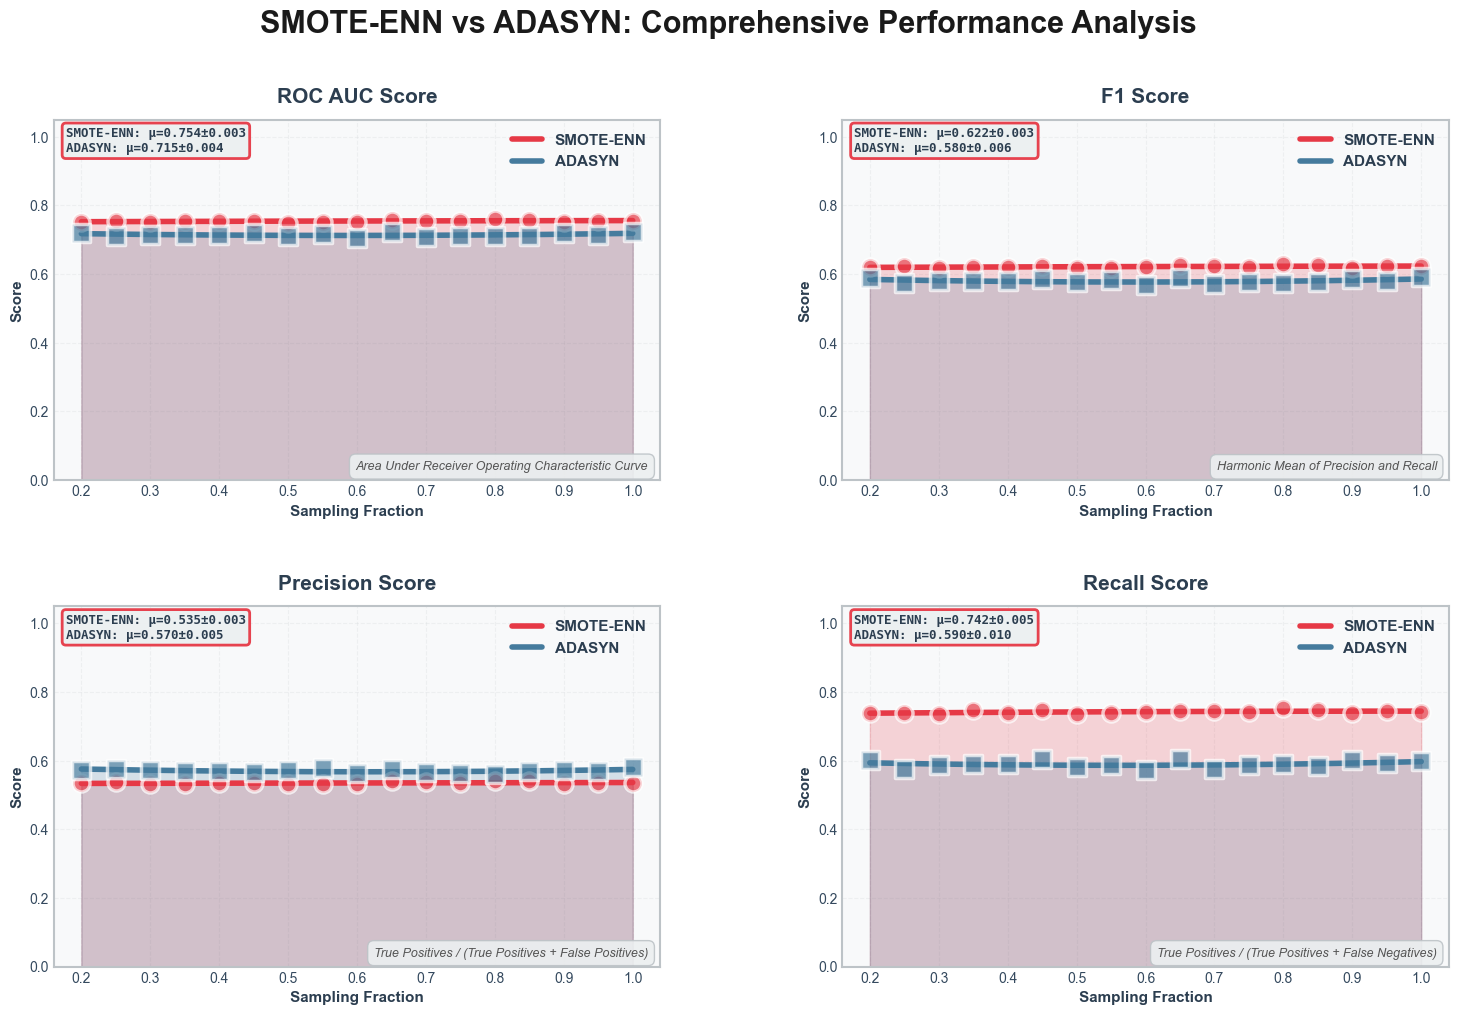

In [77]:
# Set professional light theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Create figure with light background
fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)
fig.patch.set_facecolor('#ffffff')

# Title
fig.suptitle('SMOTE-ENN vs ADASYN: Comprehensive Performance Analysis', 
             fontsize=22, fontweight='bold', color='#1a1a1a', y=0.98)

# Modern color scheme
color_enn = '#E63946'  # Vibrant red
color_ada = '#457B9D'  # Professional blue
color_enn_fill = '#E6394620'  # Transparent red
color_ada_fill = '#457B9D20'  # Transparent blue

from scipy.ndimage import uniform_filter1d

metrics_config = [
    ('roc_enn', 'roc_ada', 'ROC AUC Score', 'Area Under Receiver Operating Characteristic Curve'),
    ('f1_enn', 'f1_ada', 'F1 Score', 'Harmonic Mean of Precision and Recall'),
    ('precision_enn', 'precision_ada', 'Precision Score', 'True Positives / (True Positives + False Positives)'),
    ('recall_enn', 'recall_ada', 'Recall Score', 'True Positives / (True Positives + False Negatives)')
]

for idx, (enn_col, ada_col, metric_name, metric_desc) in enumerate(metrics_config):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    ax.set_facecolor('#f8f9fa')
    
    # Extract data for polynomial fitting
    x_data = df_result['frac'].values
    y_enn = df_result[enn_col].values
    y_ada = df_result[ada_col].values
    
    # Fit polynomials
    z_enn = np.polyfit(x_data, y_enn, 2)
    z_ada = np.polyfit(x_data, y_ada, 2)
    p_enn = np.poly1d(z_enn)
    p_ada = np.poly1d(z_ada)
    
    # Create smooth curve
    x_smooth = np.linspace(x_data.min(), x_data.max(), 300)
    y_enn_smooth = p_enn(x_smooth)
    y_ada_smooth = p_ada(x_smooth)
    
    # Plot filled areas under curves
    ax.fill_between(x_smooth, y_enn_smooth, alpha=0.2, color=color_enn, label='_nolegend_')
    ax.fill_between(x_smooth, y_ada_smooth, alpha=0.2, color=color_ada, label='_nolegend_')
    
    # Plot smooth lines
    ax.plot(x_smooth, y_enn_smooth, color=color_enn, linewidth=4, label='SMOTE-ENN', zorder=3)
    ax.plot(x_smooth, y_ada_smooth, color=color_ada, linewidth=4, label='ADASYN', zorder=3)
    
    # Plot scatter points with enhanced markers
    ax.scatter(x_data, y_enn, color=color_enn, s=150, marker='o', alpha=0.7, 
              edgecolors='white', linewidth=2.5, zorder=4, label='_nolegend_')
    ax.scatter(x_data, y_ada, color=color_ada, s=150, marker='s', alpha=0.7,
              edgecolors='white', linewidth=2.5, zorder=4, label='_nolegend_')
    
    # Calculate statistics
    enn_mean = y_enn.mean()
    ada_mean = y_ada.mean()
    enn_std = y_enn.std()
    ada_std = y_ada.std()
    
    # Enhanced title and labels
    ax.set_title(metric_name, fontsize=15, fontweight='bold', color='#2c3e50', pad=12)
    ax.text(0.98, 0.02, metric_desc, transform=ax.transAxes, fontsize=9, 
           style='italic', color='#555555', ha='right', va='bottom',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='#ecf0f1', alpha=0.9, edgecolor='#bdc3c7', linewidth=1))
    
    ax.set_xlabel('Sampling Fraction', fontsize=11, fontweight='bold', color='#2c3e50')
    ax.set_ylabel('Score', fontsize=11, fontweight='bold', color='#2c3e50')
    
    # Grid styling
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, color='#d5d8dc')
    
    # Axes styling
    ax.set_ylim([0, 1.05])
    ax.tick_params(colors='#34495e', labelsize=10)
    for spine in ax.spines.values():
        spine.set_color('#bdc3c7')
        spine.set_linewidth(1.5)
    
    # Statistics box
    stats_text = f'SMOTE-ENN: μ={enn_mean:.3f}±{enn_std:.3f}\nADASYN: μ={ada_mean:.3f}±{ada_std:.3f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
           verticalalignment='top', family='monospace', color='#2c3e50', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='#ecf0f1', edgecolor=color_enn, alpha=0.95, linewidth=2))
    
    # Enhanced legend
    legend = ax.legend(fontsize=11, loc='upper right', framealpha=0.98, 
                      edgecolor='#bdc3c7', fancybox=True, shadow=True)
    legend.get_frame().set_facecolor('#ffffff')
    for text in legend.get_texts():
        text.set_color('#2c3e50')
        text.set_fontweight('bold')

plt.tight_layout()
plt.show()


based on the results SMOTEENN performs better than ADASYN in all the metrics and it is more consistent, and hence we will go ahead with SMOTEENN for further model building and hyperparameter tuning.  

### HYPERPARAMETER TUNING